# Pre-entrega 3: Clasificador supervisado con TF-IDF

Este notebook implementa un pipeline reproducible de clasificación de texto: carga de datos, limpieza, tokenización, lematización, vectorización TF-IDF, entrenamiento con regresión logística, evaluación, predicción sobre textos nuevos y guardado del pipeline completo.

El preprocesamiento reutiliza el flujo desarrollado en `pipeline_EDA_NLP.ipynb`: limpieza con expresiones regulares, tokenización y lematización con `en_core_web_sm`. El test permanece separado para evitar data leakage.

## 1. Importación de librerías y configuración

Se importan las librerías y se fija una semilla para garantizar la reproducibilidad.

In [32]:
# 1. Importación de librerías y configuración
import html
import re
import subprocess
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

SEED = 42
np.random.seed(SEED)
workspace_root = Path(r"u:\Curso_Data\Data Science III\proy_data_science_III")
candidates = [Path.cwd(), *Path.cwd().parents, workspace_root]
ROOT = next((candidate for candidate in candidates if (candidate / "data" / "ag_news_train.csv").exists()), None)
if ROOT is None:
    raise FileNotFoundError("No se encontró data/ag_news_train.csv.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

sns.set_theme(style="whitegrid")
print(f"Directorio del proyecto: {ROOT}")
print("Modelo lingüístico: en_core_web_sm")

Directorio del proyecto: u:\Curso_Data\Data Science III\proy_data_science_III
Modelo lingüístico: en_core_web_sm


## 2. Carga y exploración del conjunto de datos

Se cargan los splits provistos y se revisan estructura, nulos, duplicados, clases y ejemplos.

In [33]:
# 2. Carga y exploración del conjunto de datos
train_path = ROOT / "data" / "ag_news_train.csv"
test_path = ROOT / "data" / "ag_news_test.csv"
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Columnas:", train_df.columns.tolist())
print("Nulos en train:\n", train_df.isna().sum())
print("Duplicados en train:", train_df.duplicated().sum())
print("Distribución de clases:\n", train_df["label"].value_counts())
display(train_df.head(3))

Train: (8000, 2)
Test: (2000, 2)
Columnas: ['text', 'label']
Nulos en train:
 text     0
label    0
dtype: int64
Duplicados en train: 0
Distribución de clases:
 label
Sci_Tech    2000
Business    2000
Sports      2000
World       2000
Name: count, dtype: int64


,text,label
0,"Red Hat Appoints New CFO. September 2, 2004 --...",Sci_Tech
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",Sci_Tech
2,Radio Outage Grounds West Coast Flights. Airpo...,Business


## 3. Preprocesamiento del texto

Se limpia el texto reutilizando la función del módulo anterior y se normaliza a minúsculas.

In [34]:
# 3. Preprocesamiento del texto
# Se reutiliza el flujo de pipeline_EDA_NLP: limpieza, tokenización y lematización.
HTML_TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    text = html.unescape(text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text.lower())
    return MULTI_SPACE_RE.sub(" ", text).strip()


def preprocess_text(text: str) -> str:
    doc = nlp(clean_text(text))
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space and not token.is_punct and len(token.lemma_) > 1
    )


def preprocess_texts(texts: pd.Series) -> pd.Series:
    return texts.fillna("").map(preprocess_text)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["text_processed"] = preprocess_texts(train_df["text"])
test_df["text_processed"] = preprocess_texts(test_df["text"])
display(train_df[["text", "text_processed"]].head(10))

,text,text_processed
0,"Red Hat Appoints New CFO. September 2, 2004 --...",red hat appoint new cfo september web host ind...
1,"Sprint, SBC In Hotspot Roaming Deal. Sprint an...",sprint sbc in hotspot roam deal sprint and sbc...
2,Radio Outage Grounds West Coast Flights. Airpo...,radio outage ground west coast flights airport...
3,Hollywood lawsuits to strike Net pirates. Holl...,hollywood lawsuit to strike net pirate hollywo...
4,Custis Takes Control. Family and Tony Robbins ...,custis take control family and tony robbin hav...
5,CA execs can keep bonuses--for now. Computer A...,can exec can keep bonus for now computer assoc...
6,"WorldCom, Microsoft cases before EU court. Two...",worldcom microsoft case before eu court two of...
7,EU Court Overturns Bar on Merger (Reuters). Re...,eu court overturn bar on merger reuter reuter ...
8,Homer-happy Mariners end skid. A four-pitch se...,homer happy mariner end skid four pitch sequen...
9,Philip Morris lab discovered passive smoking r...,philip morris lab discover passive smoking ris...


## 4. División en entrenamiento y prueba

Se conserva el test provisto y se crea una validación interna estratificada a partir de train.

In [35]:
# 4. División en entrenamiento y prueba
X = train_df["text_processed"]
y = train_df["label"]
X_test = test_df["text_processed"]
y_test = test_df["label"]
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Ajuste: {len(X_fit)} | Validación: {len(X_validation)} | Test: {len(X_test)}")

Ajuste: 6400 | Validación: 1600 | Test: 2000


## 5. Vectorización TF-IDF

Se comparan `max_features` y `ngram_range`. El vectorizador se ajusta únicamente sobre los datos de entrenamiento.

In [36]:
# 5. Vectorización TF-IDF y comparación de configuraciones
# stop_words elimina palabras funcionales; AP/ap se conserva por ser término de dominio.
vectorizer_params = {"stop_words": "english", "min_df": 2, "max_df": 0.95, "sublinear_tf": True}
configurations = [
    {"max_features": 10000, "ngram_range": (1, 1)},
    {"max_features": 20000, "ngram_range": (1, 2)},
]
validation_results = []
for config in configurations:
    candidate = Pipeline([
        ("tfidf", TfidfVectorizer(**vectorizer_params, **config)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    candidate.fit(X_fit, y_fit)
    predictions = candidate.predict(X_validation)
    validation_results.append({**config, "f1_macro_validacion": f1_score(y_validation, predictions, average="macro")})
validation_results_df = pd.DataFrame(validation_results).sort_values("f1_macro_validacion", ascending=False)
display(validation_results_df)
best_configuration = validation_results_df.iloc[0].to_dict()
print("Mejor configuración:", best_configuration)

,max_features,ngram_range,f1_macro_validacion
1,20000,"(1, 2)",0.892736
0,10000,"(1, 1)",0.890195


Mejor configuración: {'max_features': 20000, 'ngram_range': (1, 2), 'f1_macro_validacion': 0.8927362680480999}


## 6. Entrenamiento del modelo de clasificación

Se entrena `LogisticRegression` dentro de un `Pipeline`, apropiado para matrices dispersas TF-IDF.

In [37]:
# 6. Entrenamiento del modelo de clasificación
# LogisticRegression es eficiente con matrices dispersas y sirve como baseline.
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**vectorizer_params, max_features=int(best_configuration["max_features"]), ngram_range=best_configuration["ngram_range"])),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
])
final_pipeline.fit(X, y)
X_train_tfidf = final_pipeline.named_steps["tfidf"].transform(X)
X_test_tfidf = final_pipeline.named_steps["tfidf"].transform(X_test)
print("X_train TF-IDF:", X_train_tfidf.shape)
print("X_test TF-IDF:", X_test_tfidf.shape)

X_train TF-IDF: (8000, 20000)
X_test TF-IDF: (2000, 20000)


## 7. Evaluación con métricas

Se calculan accuracy, precision, recall y F1-score con promedios macro y ponderado.

In [38]:
# 7. Evaluación con métricas
predictions = final_pipeline.predict(X_test)
metrics = {
    "accuracy": accuracy_score(y_test, predictions),
    "precision_macro": precision_score(y_test, predictions, average="macro"),
    "recall_macro": recall_score(y_test, predictions, average="macro"),
    "f1_macro": f1_score(y_test, predictions, average="macro"),
    "precision_weighted": precision_score(y_test, predictions, average="weighted"),
    "recall_weighted": recall_score(y_test, predictions, average="weighted"),
    "f1_weighted": f1_score(y_test, predictions, average="weighted"),
}
display(pd.DataFrame([metrics]).T.rename(columns={0: "valor"}))

,valor
accuracy,0.896000
precision_macro,0.896151
recall_macro,0.896000
f1_macro,0.896003
precision_weighted,0.896151
recall_weighted,0.896000
f1_weighted,0.896003


## 8. Matriz de confusión y reporte de clasificación

Se visualizan los aciertos y errores por clase mediante `classification_report` y una matriz de confusión.

              precision    recall  f1-score   support

    Business       0.85      0.86      0.85       500
    Sci_Tech       0.87      0.87      0.87       500
      Sports       0.95      0.96      0.96       500
       World       0.91      0.89      0.90       500

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



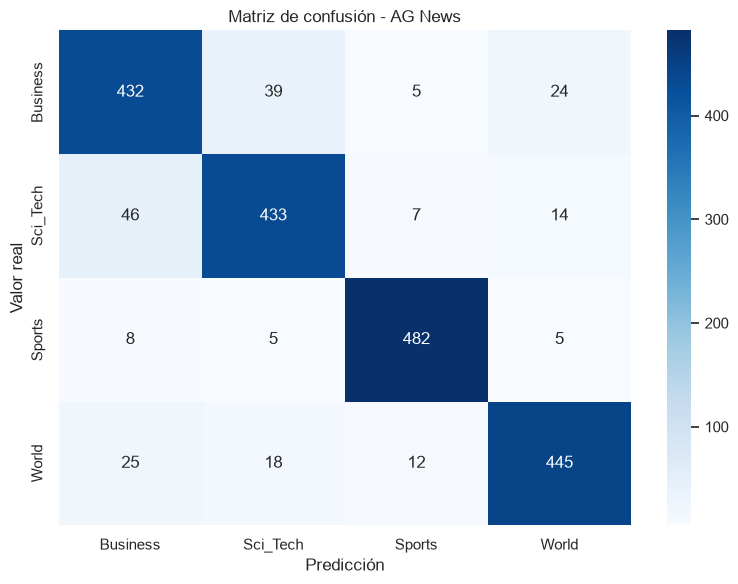

In [39]:
# 8. Matriz de confusión y reporte de clasificación
labels = sorted(y_test.unique())
print(classification_report(y_test, predictions, target_names=labels))
confusion = confusion_matrix(y_test, predictions, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - AG News")
plt.tight_layout()
plt.show()

## 9. Prueba con nuevas entradas

Se predicen categorías para textos nuevos y se muestran las probabilidades estimadas.

In [40]:
# 9. Prueba con nuevas entradas
new_texts = pd.Series([
    "The company reported higher quarterly profits after strong market demand.",
    "The team won the championship after scoring in the final minute.",
    "Scientists announced a new discovery in space technology.",
    "World leaders met to discuss an international peace agreement.",
])
new_predictions = final_pipeline.predict(preprocess_texts(new_texts))
new_probabilities = final_pipeline.predict_proba(preprocess_texts(new_texts))
display(pd.DataFrame({
    "texto": new_texts,
    "clase_predicha": new_predictions,
    "confianza_maxima": new_probabilities.max(axis=1),
}))

,texto,clase_predicha,confianza_maxima
0,The company reported higher quarterly profits ...,Business,0.861250
1,The team won the championship after scoring in...,Sports,0.975801
2,Scientists announced a new discovery in space ...,Sci_Tech,0.991075
3,World leaders met to discuss an international ...,World,0.535548


## 10. Guardado del pipeline completo

Se serializa el vectorizador y el clasificador juntos en un archivo `.joblib` reutilizable.

In [41]:
# 10. Guardado del pipeline completo
model_path = ROOT / "modelo_tfidf_ag_news.joblib"
joblib.dump(final_pipeline, model_path)
loaded_pipeline = joblib.load(model_path)
print(f"Pipeline guardado en: {model_path}")
print("Comprobación:", loaded_pipeline.predict(pd.Series(["A new football team won the game."]))[0])

Pipeline guardado en: u:\Curso_Data\Data Science III\proy_data_science_III\modelo_tfidf_ag_news.joblib
Comprobación: Sports
